# COMP4131 - Data Modelling and Analysis - Coursework 2
# House Price Prediction using Machine Learning

## Introduction

This notebook investigates the problem of house price prediction using a real-world housing dataset. The objective is to analyse the relationship between property features and housing prices, and to build predictive models that can accurately estimate property values.

A range of machine learning models are explored, including Linear Regression, Random Forest, XGBoost, and Multi-Layer Perceptron (MLP). In addition, an ensemble stacking model is developed to improve predictive performance.

The study also evaluates the impact of data preprocessing techniques, such as outlier removal, feature engineering, and feature selection, on model performance.

The results are analysed using standard regression metrics, including Root Mean Squared Error (RMSE) and the coefficient of determination ($R^2$).

## Import Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
from matplotlib.ticker import StrMethodFormatter
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.base import clone

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, r2_score

from xgboost import XGBRegressor
import shap

sns.set(style="whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

## Dataset Overview

The dataset used in this study is loaded from a local file and contains information on residential properties. It includes both structural features (such as bedrooms, bathrooms, and living area) and location-related attributes.

This section provides an overview of the dataset, including its size, feature types, and basic statistical properties. Understanding the structure of the dataset is essential before applying further preprocessing and modelling steps.

In [2]:
df_original = pd.read_csv("data.csv")
df = df_original.copy()

print("Dataset shape:", df.shape)
df.head()
df.info()
df.describe()

Dataset shape: (4600, 18)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           4600 non-null   object 
 1   price          4600 non-null   float64
 2   bedrooms       4600 non-null   float64
 3   bathrooms      4600 non-null   float64
 4   sqft_living    4600 non-null   int64  
 5   sqft_lot       4600 non-null   int64  
 6   floors         4600 non-null   float64
 7   waterfront     4600 non-null   int64  
 8   view           4600 non-null   int64  
 9   condition      4600 non-null   int64  
 10  sqft_above     4600 non-null   int64  
 11  sqft_basement  4600 non-null   int64  
 12  yr_built       4600 non-null   int64  
 13  yr_renovated   4600 non-null   int64  
 14  street         4600 non-null   object 
 15  city           4600 non-null   object 
 16  statezip       4600 non-null   object 
 17  country        4600 non-nu

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated
count,4.600000e+03,4600.000000,4600.000000,4600.000000,4.600000e+03,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000
mean,5.519630e+05,3.400870,2.160815,2139.346957,1.485252e+04,1.512065,0.007174,0.240652,3.451739,1827.265435,312.081522,1970.786304,808.608261
std,5.638347e+05,0.908848,0.783781,963.206916,3.588444e+04,0.538288,0.084404,0.778405,0.677230,862.168977,464.137228,29.731848,979.414536
min,0.000000e+00,0.000000,0.000000,370.000000,6.380000e+02,1.000000,0.000000,0.000000,1.000000,370.000000,0.000000,1900.000000,0.000000
25%,3.228750e+05,3.000000,1.750000,1460.000000,5.000750e+03,1.000000,0.000000,0.000000,3.000000,1190.000000,0.000000,1951.000000,0.000000
50%,4.609435e+05,3.000000,2.250000,1980.000000,7.683000e+03,1.500000,0.000000,0.000000,3.000000,1590.000000,0.000000,1976.000000,0.000000
75%,6.549625e+05,4.000000,2.500000,2620.000000,1.100125e+04,2.000000,0.000000,0.000000,4.000000,2300.000000,610.000000,1997.000000,1999.000000
max,2.659000e+07,9.000000,8.000000,13540.000000,1.074218e+06,3.500000,1.000000,4.000000,5.000000,9410.000000,4820.000000,2014.000000,2014.000000


## Missing Value Analysis

In this section, missing values are analysed to assess data completeness and quality.  
The number and proportion of missing values are calculated for each feature, allowing the identification of any incomplete variables.

This step is important because missing data can negatively affect model performance and may require appropriate handling strategies.  

If no missing values are detected, the dataset can be considered complete, and no imputation is required.

In [3]:
missing = df.isnull()

null_counts = missing.sum()
null_percent = missing.mean() * 100

missing_summary = pd.concat(
    [null_counts, null_percent],
    axis=1,
    keys=["Total", "Percentage"]
)

missing_summary = missing_summary[missing_summary["Total"] > 0].sort_values(
    by="Percentage", ascending=False
)

print("Columns with missing values:")
display(missing_summary)

if not missing_summary.empty:
    plt.figure(figsize=(12, 6))
    sns.heatmap(df[missing_summary.index].isnull(), cbar=False, cmap="viridis")
    plt.title("Heatmap of Missing Values")
    plt.xlabel("Features with Missing Data")
    plt.show()
else:
    print("No missing values detected.")

Columns with missing values:


,Total,Percentage


No missing values detected.


## Exploratory Data Analysis (EDA)

### Target Variable Analysis

The distribution of the target variable (*price*) is analysed using a histogram with kernel density estimation (KDE) to assess its shape and skewness. The skewness statistic is also computed to quantify asymmetry.

This analysis helps determine whether transformations (e.g., logarithmic scaling) are required to improve model performance.

### Relationship Between Features and Price

Relationships between key features and house price are explored using visualisation techniques.

A regression plot is used to examine the relationship between *sqft_living* and *price*, with the correlation coefficient indicating the strength of association. 

Categorical features such as *waterfront* and *view* are analysed using boxplots, while additional variables (e.g., *bedrooms*, *bathrooms*, *sqft_above*) are examined to assess their influence on pricing.

These analyses provide insights that guide feature engineering and model design.

Skewness of Price: 24.79


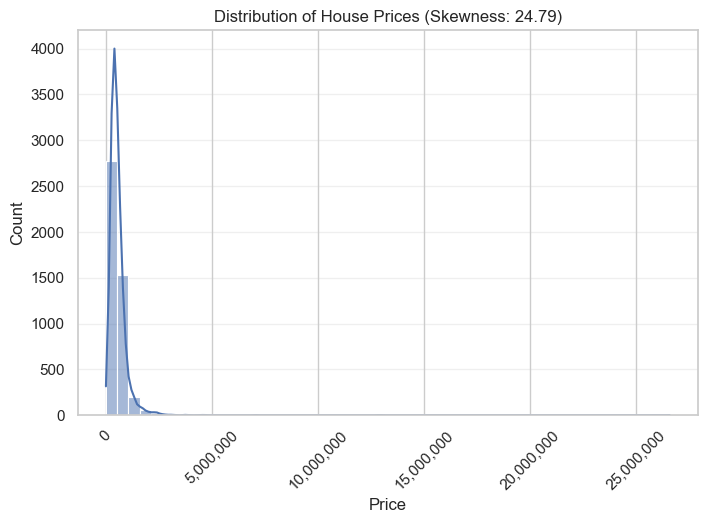

In [4]:
price_skew = df["price"].skew()
print(f"Skewness of Price: {price_skew:.2f}")

plt.figure(figsize=(8, 5))
sns.histplot(df["price"], bins=50, kde=True)

plt.gca().xaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))
plt.title(f"Distribution of House Prices (Skewness: {price_skew:.2f})")
plt.xlabel("Price")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)
plt.show()

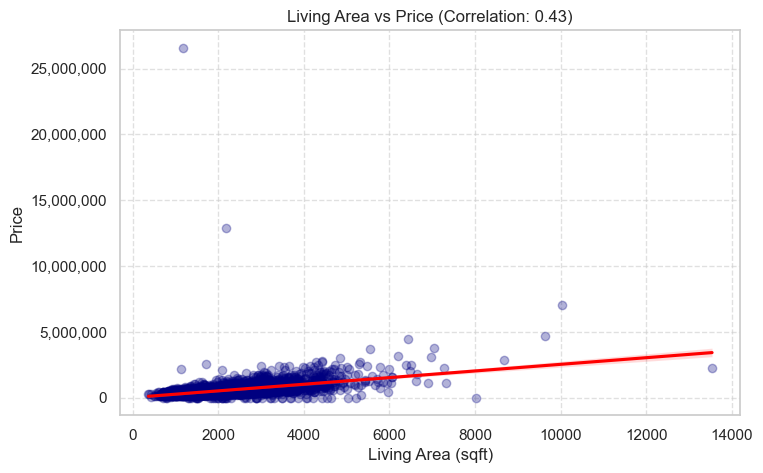

In [5]:
correlation = df["sqft_living"].corr(df["price"])

plt.figure(figsize=(8, 5))
sns.regplot(
    x="sqft_living",
    y="price",
    data=df,
    scatter_kws={"alpha": 0.3, "color": "navy"},
    line_kws={"color": "red"}
)

plt.gca().yaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))
plt.title(f"Living Area vs Price (Correlation: {correlation:.2f})")
plt.xlabel("Living Area (sqft)")
plt.ylabel("Price")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

## Correlation Analysis

This section examines the relationships between numerical features using a correlation matrix.

A heatmap is used to visualise pairwise correlations, helping to identify strong relationships and potential multicollinearity. To improve readability, a triangular mask is applied to display only the upper half of the matrix.

A two-layer visualisation approach is used: a greyed-out lower triangle reduces visual clutter, while the upper triangle highlights correlation values using a diverging colour map with annotations. This enhances clarity and emphasises key relationships between features.

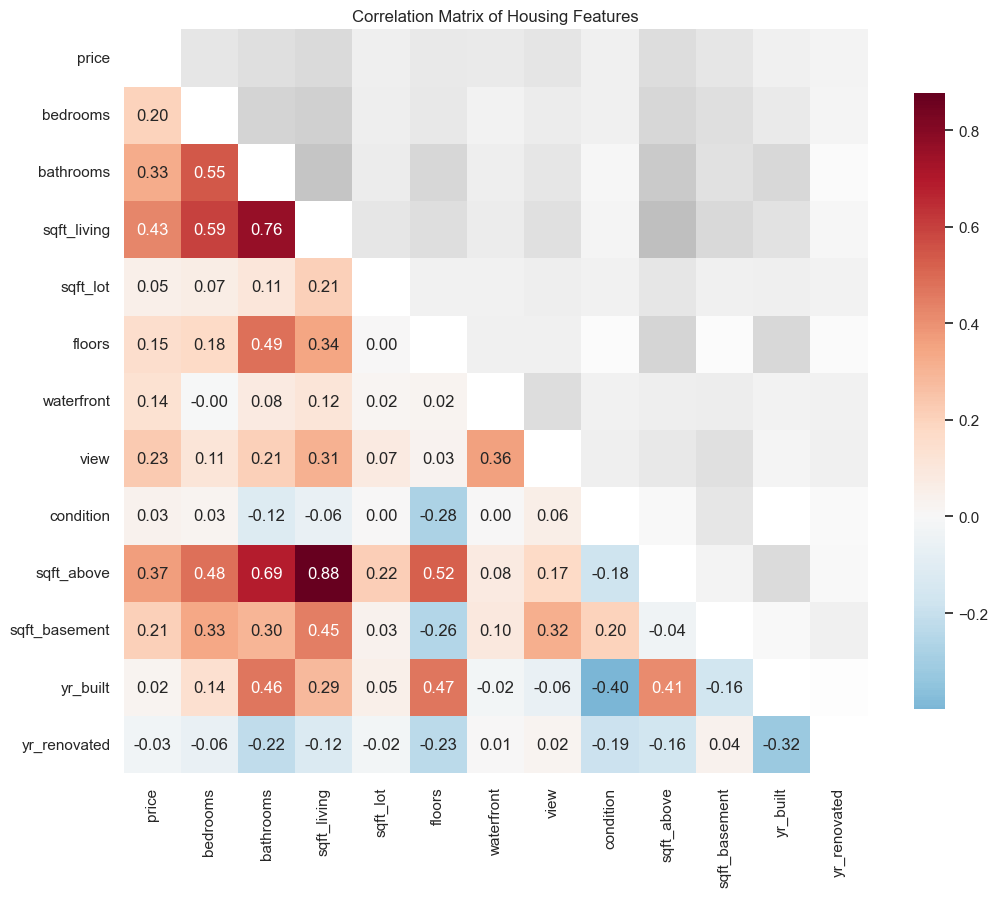

In [6]:
corr = df.corr(numeric_only=True)

mask_lower = np.tril(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(12, 10))

sns.set_style("white")

sns.heatmap(
    corr,
    mask=mask_lower,
    cmap="Greys",
    cbar=False,
    square=True,
    linewidths=0,     
    alpha=0.25       
)

sns.heatmap(
    corr,
    mask=np.triu(np.ones_like(corr, dtype=bool)),
    annot=True,
    fmt=".2f",
    cmap='RdBu_r',
    center=0,
    square=True,
    linewidths=0,    
    cbar_kws={"shrink": .8}
)

plt.gca().set_facecolor('white')

plt.title("Correlation Matrix of Housing Features")
# plt.savefig("correlation_heatmap.png", bbox_inches='tight') 
plt.show()

### Analysis of Categorical Features

To investigate the influence of selected categorical variables on house prices, several visualisations are conducted.

A bar plot is used to analyse the average house price across different cities, with cities ranked by their mean prices. This highlights significant geographical variation, indicating that location is a key determinant of property value.

Boxplots are used to evaluate the impact of categorical features such as *waterfront* and *view*. Waterfront properties are generally associated with higher prices, while higher *view* ratings correspond to higher price distributions.

These findings confirm that location and environmental attributes play an important role in house price prediction and should be incorporated into the modelling process.

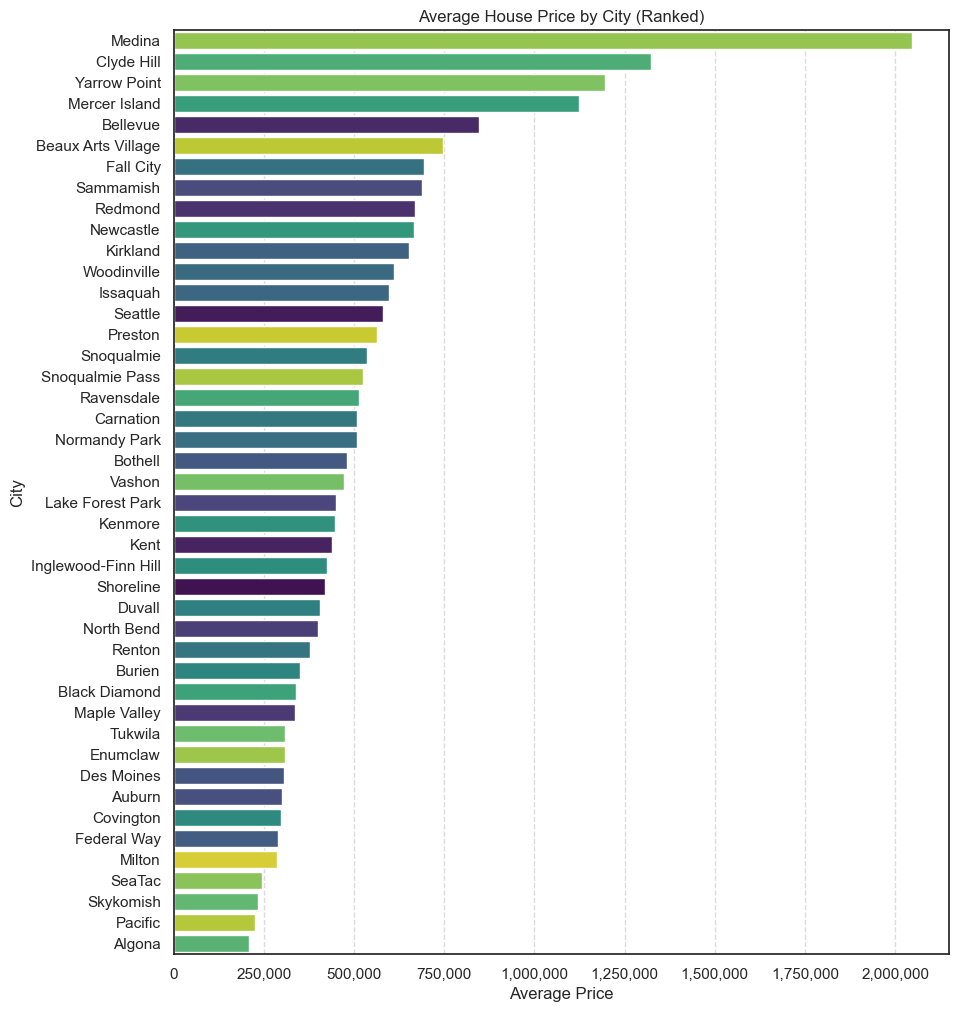

In [7]:
city_order = df.groupby('city')['price'].mean().sort_values(ascending=False).index

plt.figure(figsize=(10, 12))
sns.barplot(
    x="price", 
    y="city", 
    data=df, 
    order=city_order, 
    hue="city",          
    palette="viridis", 
    legend=False,        
    estimator=np.mean, 
    errorbar=None
)

plt.gca().xaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))

plt.title("Average House Price by City (Ranked)")
plt.xlabel("Average Price")
plt.ylabel("City")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

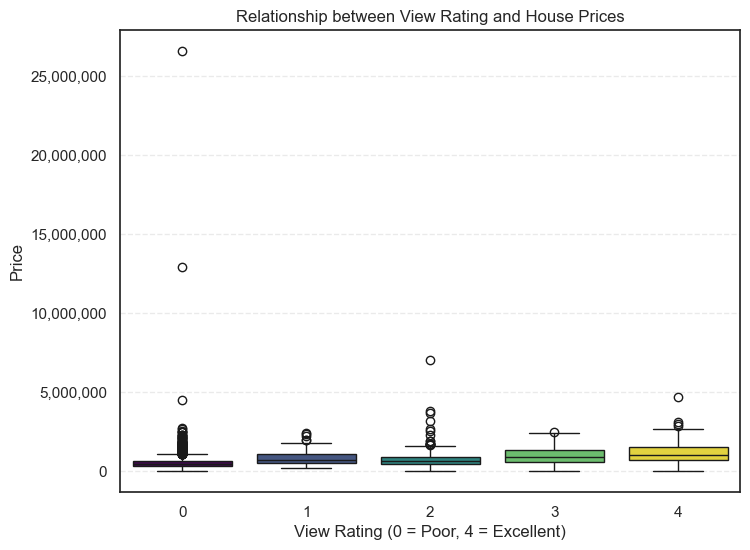

In [8]:
plt.figure(figsize=(8, 6))

sns.boxplot(
    x="view", 
    y="price", 
    data=df, 
    hue="view", 
    palette="viridis", 
    legend=False
)

plt.gca().yaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))

plt.title("Relationship between View Rating and House Prices")
plt.xlabel("View Rating (0 = Poor, 4 = Excellent)")
plt.ylabel("Price")
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.show()

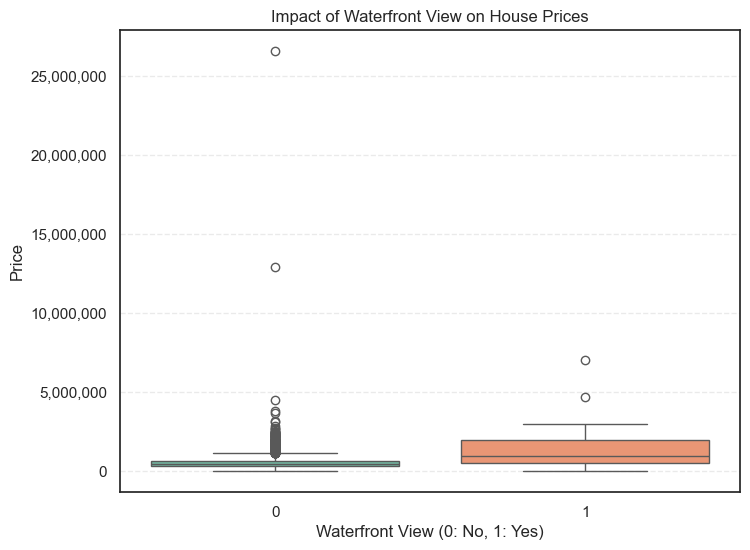

In [9]:
plt.figure(figsize=(8, 6))

sns.boxplot(
    x="waterfront", 
    y="price", 
    data=df, 
    hue="waterfront", 
    palette="Set2", 
    legend=False
)

plt.gca().yaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))

plt.title("Impact of Waterfront View on House Prices")
plt.xlabel("Waterfront View (0: No, 1: Yes)")
plt.ylabel("Price")
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.show()

## Data Cleaning

To improve data quality and reduce the influence of extreme values, outliers in the target variable (*price*) are removed using a percentile-based filtering approach.

Specifically, observations above the 99th percentile are considered extreme values and are excluded from the dataset. This approach focuses on removing unusually high-priced properties that may distort the distribution and negatively affect model performance.

The number and proportion of removed observations are calculated to quantify the impact of this filtering process. In addition, boxplots are used to visually compare the distribution of house prices before and after outlier removal.

This process reduces the influence of extreme values, leading to a more stable distribution and improving the robustness of subsequent modelling steps.

Original data size: 4600
After removing outliers: 4554
Number of removed outliers: 46
Percentage removed: 1.00%


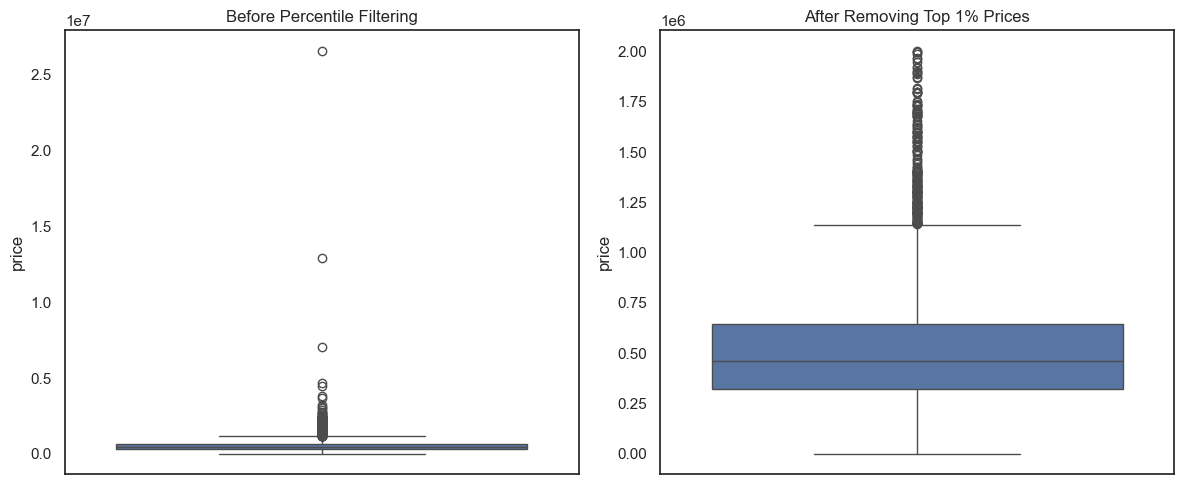

df: (4600, 18)
df_cleaned: (4554, 18)


In [10]:
original_size = df.shape[0]

df_cleaned = df[df["price"] < df["price"].quantile(0.99)].copy()

removed = original_size - df_cleaned.shape[0]
removed_pct = removed / original_size * 100

print("Original data size:", original_size)
print("After removing outliers:", df_cleaned.shape[0])
print("Number of removed outliers:", removed)
print(f"Percentage removed: {removed_pct:.2f}%")

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.boxplot(y=df["price"])
plt.title("Before Percentile Filtering")

plt.subplot(1, 2, 2)
sns.boxplot(y=df_cleaned["price"])
plt.title("After Removing Top 1% Prices")

plt.tight_layout()
plt.show()

print("df:", df.shape)
print("df_cleaned:", df_cleaned.shape)


### Log Transformation Analysis

To address the strong positive skewness in the target variable (*price*), a logarithmic transformation is applied using \( \log(1 + price) \).

The original price distribution exhibits a long right tail, which can negatively affect model performance and lead to biased predictions. The log transformation reduces the impact of extreme values and stabilises variance.

Histograms with kernel density estimation (KDE) are used to compare the distributions before and after transformation. The transformed distribution appears more symmetric and closer to a normal distribution.

Skewness values are calculated for both variables, confirming a reduction in skewness after transformation.

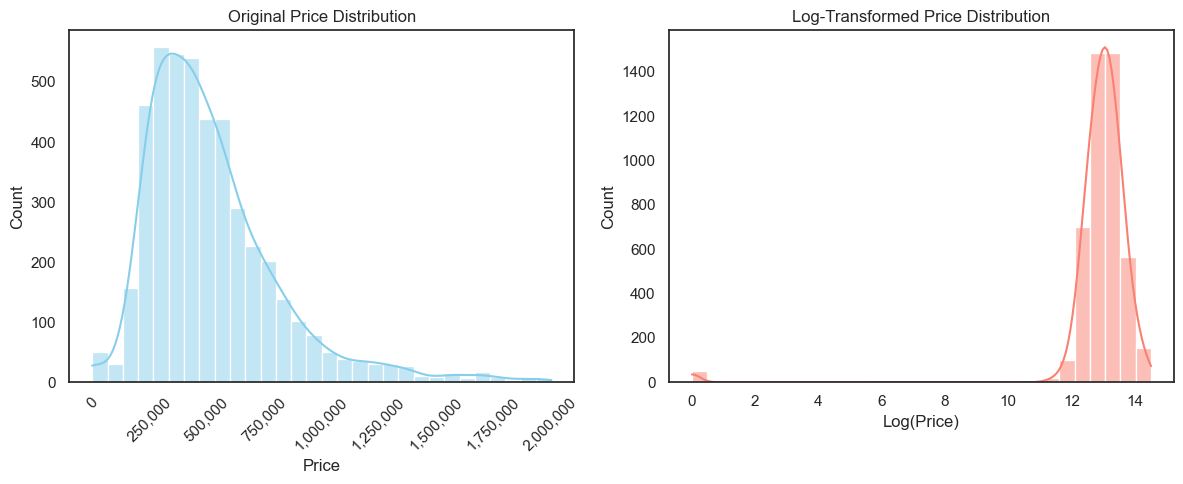

Skewness before: 1.5957007585451963
Skewness after: -7.726211569319779


In [11]:
df_log = df_cleaned.copy()
df_log["log_price"] = np.log1p(df_log["price"])

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df_log["price"], bins=30, kde=True, color="skyblue")
plt.title("Original Price Distribution")
plt.gca().xaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))
plt.xlabel("Price")
plt.xticks(rotation=45)

plt.subplot(1, 2, 2)
sns.histplot(df_log["log_price"], bins=30, kde=True, color="salmon")
plt.title("Log-Transformed Price Distribution")
plt.xlabel("Log(Price)")

plt.tight_layout()
plt.show()

print("Skewness before:", df_log["price"].skew())
print("Skewness after:", df_log["log_price"].skew())

## Feature Engineering

To enhance the predictive capability of the dataset, several feature engineering techniques were applied. These transformations aim to extract meaningful information, reduce skewness, and capture domain-specific relationships.

First, temporal features were extracted from the transaction date, including *year* and *month*. These were further transformed into seasonal categories to capture potential temporal patterns in house prices.

Second, structural features were derived to represent property characteristics more effectively. The feature *house_age* was computed as the difference between transaction year and construction year. Additionally, renovation-related features such as *is_renovated* and *year_since_renovation* were created to capture both the presence and recency of property upgrades.

Third, ratio-based features were introduced to model relative relationships between variables. For example, *basement_ratio* represents the proportion of basement area relative to living space, while *bath_bed_ratio* captures the relationship between bathrooms and bedrooms. A binary feature *has_basement* was also included to indicate the presence of basement space.

Fourth, a composite feature *total_sqft* was constructed by combining living area and lot size. Its logarithmic transformation (*log_total_sqft*) was applied to reduce skewness and improve linearity.

Finally, location information was processed by extracting zip codes from the original statezip field. These were later used for target encoding to capture location-based pricing patterns.

Overall, these engineered features improve the expressiveness of the dataset and enable models to capture more complex relationships.

In [12]:
df_fe = df_cleaned.copy()

df_fe["date"] = pd.to_datetime(df_fe["date"])
df_fe["year"] = df_fe["date"].dt.year
df_fe["month"] = df_fe["date"].dt.month

print(df_fe[["year", "month"]].head())

   year  month
0  2014      5
2  2014      5
3  2014      5
4  2014      5
5  2014      5


In [13]:
df_fe["house_age"] = df_fe["year"] - df_fe["yr_built"]
df_fe["is_renovated"] = (df_fe["yr_renovated"] > 0).astype(int)
df_fe["year_since_renovation"] = np.where(
    df_fe["yr_renovated"] == 0,
    0,
    df_fe["year"] - df_fe["yr_renovated"]
)


df_fe[["house_age", "is_renovated", "year_since_renovation"]].head()

,house_age,is_renovated,year_since_renovation
0,59,1,9
2,48,0,0
3,51,0,0
4,38,1,22
5,76,1,20


In [14]:
season_map = {
    12: "winter", 1: "winter", 2: "winter",
    3: "spring", 4: "spring", 5: "spring",
    6: "summer", 7: "summer", 8: "summer",
    9: "autumn", 10: "autumn", 11: "autumn"
}

df_fe["season"] = df_fe["month"].map(season_map)

df_fe["season"].value_counts()

season
summer    2802
spring    1752
Name: count, dtype: int64

In [15]:
EPS = 1e-6
df_fe["basement_ratio"] = df_fe["sqft_basement"] / (df_fe["sqft_living"] + EPS)
df_fe["bath_bed_ratio"] = df_fe["bathrooms"] / (df_fe["bedrooms"] + EPS)
df_fe["has_basement"] = (df_fe["sqft_basement"] > 0).astype(int)

df_fe["basement_ratio"] = df_fe["basement_ratio"].clip(upper=df_fe["basement_ratio"].quantile(0.99))
df_fe["bath_bed_ratio"] = df_fe["bath_bed_ratio"].clip(upper=df_fe["bath_bed_ratio"].quantile(0.99))

df_fe["total_sqft"] = df_fe["sqft_living"] + df_fe["sqft_lot"]
df_fe["log_total_sqft"] = np.log1p(df_fe["total_sqft"])


print("Feature Engineering Preview:")

display(df_fe[[
    "basement_ratio",
    "bath_bed_ratio",
    "has_basement",
    "total_sqft",
    "log_total_sqft"
]].head())

Feature Engineering Preview:


,basement_ratio,bath_bed_ratio,has_basement,total_sqft,log_total_sqft
0,0.000000,0.500000,0,9252,9.132703
2,0.000000,0.666666,0,13877,9.538060
3,0.500000,0.750000,1,10030,9.213436
4,0.412371,0.625000,1,12440,9.428753
5,0.000000,0.500000,0,7260,8.890273


In [16]:
df_fe[["state", "zip"]] = df_fe["statezip"].str.split(" ", expand=True)

df_fe = df_fe.dropna(subset=["zip"])

df_fe["zip"] = df_fe["zip"].astype(int)

if df_fe["state"].nunique() == 1:
    df_fe = df_fe.drop(columns=["state"])

df_fe = df_fe.drop(columns=["statezip"])

print("State/Zip processed")
display(df_fe[["zip"]].head())

State/Zip processed


,zip
0,98133
2,98042
3,98008
4,98052
5,98115


### Feature Engineering Validation and Visualisation

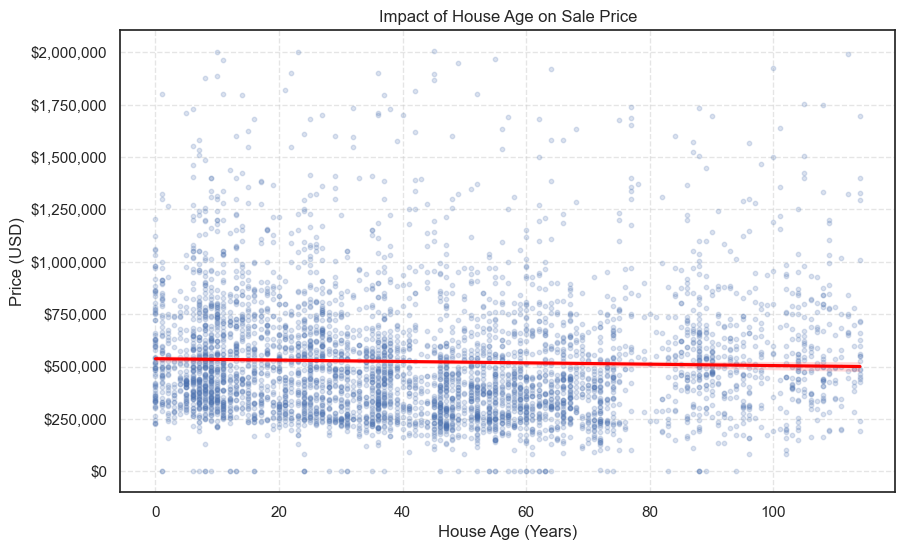

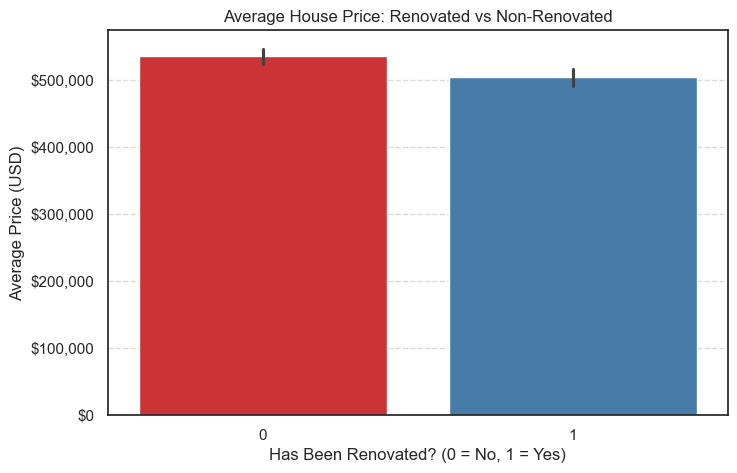

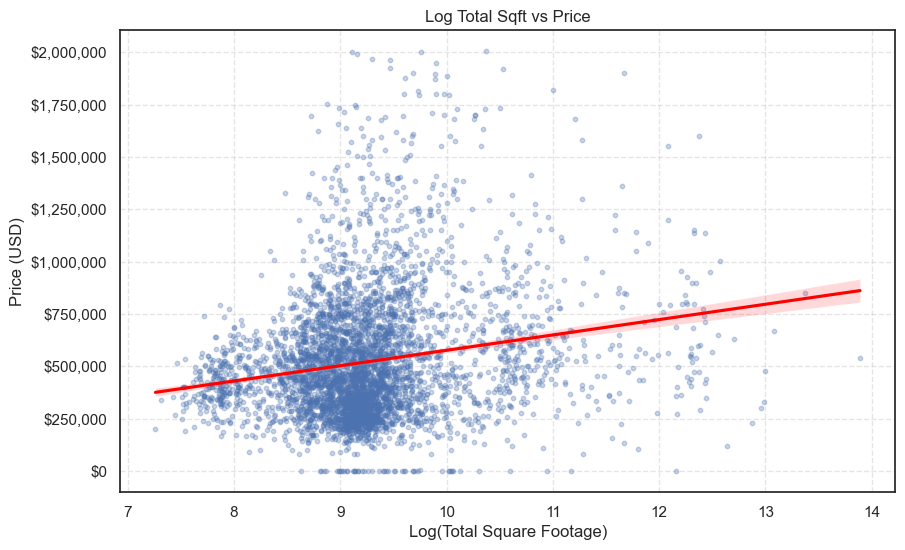

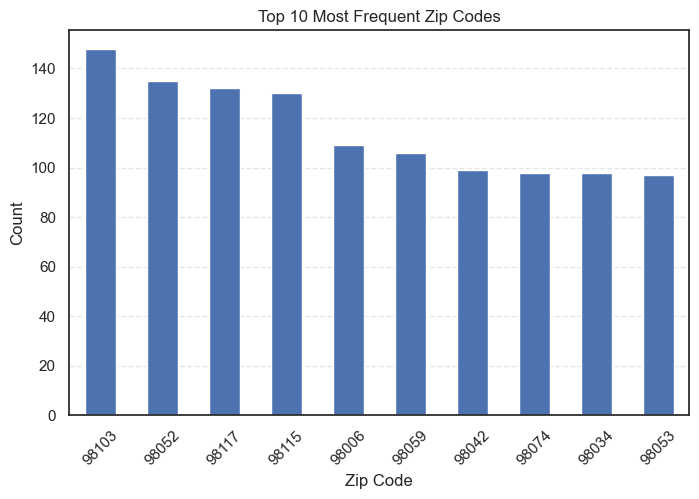

In [17]:
plt.figure(figsize=(10, 6))
sns.regplot(
    x="house_age",
    y="price",
    data=df_fe,
    scatter_kws={"alpha": 0.2, "s": 10},
    line_kws={"color": "red"}
)
plt.gca().yaxis.set_major_formatter(StrMethodFormatter('${x:,.0f}'))
plt.title("Impact of House Age on Sale Price")
plt.xlabel("House Age (Years)")
plt.ylabel("Price (USD)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()


plt.figure(figsize=(8, 5))
sns.barplot(
    x="is_renovated",
    y="price",
    data=df_fe,
    hue="is_renovated",
    palette="Set1",
    legend=False
)
plt.gca().yaxis.set_major_formatter(StrMethodFormatter('${x:,.0f}'))
plt.title("Average House Price: Renovated vs Non-Renovated")
plt.xlabel("Has Been Renovated? (0 = No, 1 = Yes)")
plt.ylabel("Average Price (USD)")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()


plt.figure(figsize=(10, 6))
sns.regplot(
    x="log_total_sqft",
    y="price",
    data=df_fe,
    scatter_kws={"alpha": 0.3, "s": 10},
    line_kws={"color": "red"}
)
plt.gca().yaxis.set_major_formatter(StrMethodFormatter('${x:,.0f}'))
plt.title("Log Total Sqft vs Price")
plt.xlabel("Log(Total Square Footage)")
plt.ylabel("Price (USD)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

plt.figure(figsize=(8, 5))

df_fe["zip"].value_counts().head(10).plot(kind="bar")

plt.title("Top 10 Most Frequent Zip Codes")
plt.xlabel("Zip Code")
plt.ylabel("Count")

plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

## Final Feature Selection

Feature selection was performed using a combination of data-driven and domain-driven approaches.

First, correlation analysis was conducted using the training dataset to identify features strongly associated with the target variable. In this study, the log-transformed target variable (*log_price*) was used to ensure consistency with the modelling process. Features with an absolute correlation greater than 0.2 were retained.

Second, domain knowledge was incorporated by manually including important features such as *waterfront*, *view*, *is_renovated*, and *house_age*, even if their correlation was moderate. Additionally, the target-encoded feature *zip_te* was explicitly retained due to its ability to capture location-based pricing effects.

Third, multicollinearity was addressed by removing highly correlated features (correlation > 0.8). However, key features such as *sqft_living* were preserved to maintain interpretability.

In addition, the engineered feature *log_total_sqft* was retained to capture the overall size of the property while reducing skewness and improving linearity.

The final feature set used for modelling includes:

- sqft_living  
- bath_bed_ratio  
- bedrooms  
- bathrooms  
- sqft_basement  
- city_Mercer Island  
- city_Bellevue  
- zip_te  
- view  
- floors  
- is_renovated  
- waterfront  
- house_age  
- log_total_sqft  

These features represent a balance between statistical relevance and domain interpretability, ensuring a robust and generalisable model.

In [18]:
df_model = df_fe.copy()

df_model = df_model.drop(
    columns=["street", "country", "date", "sqft_above", "sqft_basement", "yr_built", "yr_renovated"],
    errors="ignore"
)

print("Remaining columns:", df_model.columns.tolist())

Remaining columns: ['price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'city', 'year', 'month', 'house_age', 'is_renovated', 'year_since_renovation', 'season', 'basement_ratio', 'bath_bed_ratio', 'has_basement', 'total_sqft', 'log_total_sqft', 'zip']


In [19]:
df_model = pd.get_dummies(df_model, drop_first=True)

print("Shape after encoding:", df_model.shape)

df_model = df_model.apply(
    lambda col: col.astype(int) if col.dtype == 'bool' else col
)

non_numeric_cols = df_model.select_dtypes(exclude=[np.number]).columns.tolist()

print("Non-numeric columns:", non_numeric_cols)

Shape after encoding: (4554, 64)
Non-numeric columns: []


## Train-Test Split and Feature Scaling

In [20]:
X = df_model.drop(columns=["price"])
y = df_model["price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (3643, 63)
Test shape: (911, 63)


In [21]:

X_train = X_train.copy()
X_test = X_test.copy()

X_train["zip"] = df_fe["zip"].reindex(X_train.index).astype(str)
X_test["zip"] = df_fe["zip"].reindex(X_test.index).astype(str)

zip_mean = X_train.assign(price=y_train).groupby("zip")["price"].mean()

X_train["zip_te"] = X_train["zip"].map(zip_mean)
X_test["zip_te"] = X_test["zip"].map(zip_mean)

X_test["zip_te"] = X_test["zip_te"].fillna(y_train.mean())

X_train = X_train.drop(columns=["zip"] + [c for c in X_train.columns if c.startswith("zip_") and c != "zip_te"])
X_test = X_test.drop(columns=["zip"] + [c for c in X_test.columns if c.startswith("zip_") and c != "zip_te"])

print("Target encoding done. zip_te ready.")

Target encoding done. zip_te ready.


In [22]:
train_df = pd.concat([X_train, y_train], axis=1)
train_df["log_price"] = np.log1p(train_df["price"])

corr = train_df.corr(numeric_only=True)
#corr_price = corr["price"].abs().sort_values(ascending=False)
corr_price = corr["log_price"].abs().sort_values(ascending=False)

selected_features = [
    f for f in corr_price.index
    if f not in ["price", "log_price"] and corr_price[f] > 0.1
]

important_features = [
    "sqft_living",
    "bedrooms",
    "bathrooms",
    "floors",
    "view",
    "waterfront",
    "is_renovated",
    "house_age",
    "bath_bed_ratio",
    "log_total_sqft",
    "city_Bellevue",
    "city_Mercer Island"
]

important_features = [f for f in important_features if f in X_train.columns]

selected_features = list(set(selected_features + important_features))


if "zip_te" in X_train.columns and "zip_te" not in selected_features:
    selected_features.append("zip_te")

print("Selected features:")
print(selected_features)

Selected features:
['city_Clyde Hill', 'is_renovated', 'log_total_sqft', 'house_age', 'city_Mercer Island', 'city_Bellevue', 'zip_te', 'floors', 'bedrooms', 'view', 'bath_bed_ratio', 'waterfront', 'sqft_living', 'bathrooms']


In [23]:
corr_selected = train_df[selected_features].corr().abs()

upper = corr_selected.where(
    np.triu(np.ones(corr_selected.shape), k=1).astype(bool)
)

to_drop = [
    col for col in upper.columns
    if any(upper[col] > 0.8)
]

if len(to_drop) == 0:
    print("No highly correlated features detected (threshold = 0.8).")
else:
    print("Features removed due to multicollinearity:", to_drop)

core_features = ["sqft_living"]

to_drop = [f for f in to_drop if f not in core_features]

print("Adjusted drop list:", to_drop)

final_features = [
    f for f in selected_features if f not in to_drop
]

if "zip_te" in selected_features and "zip_te" not in final_features:
    final_features.append("zip_te")

print("\nFinal features:")
print(final_features)
print("Number of features:", len(final_features))


No highly correlated features detected (threshold = 0.8).
Adjusted drop list: []

Final features:
['city_Clyde Hill', 'is_renovated', 'log_total_sqft', 'house_age', 'city_Mercer Island', 'city_Bellevue', 'zip_te', 'floors', 'bedrooms', 'view', 'bath_bed_ratio', 'waterfront', 'sqft_living', 'bathrooms']
Number of features: 14


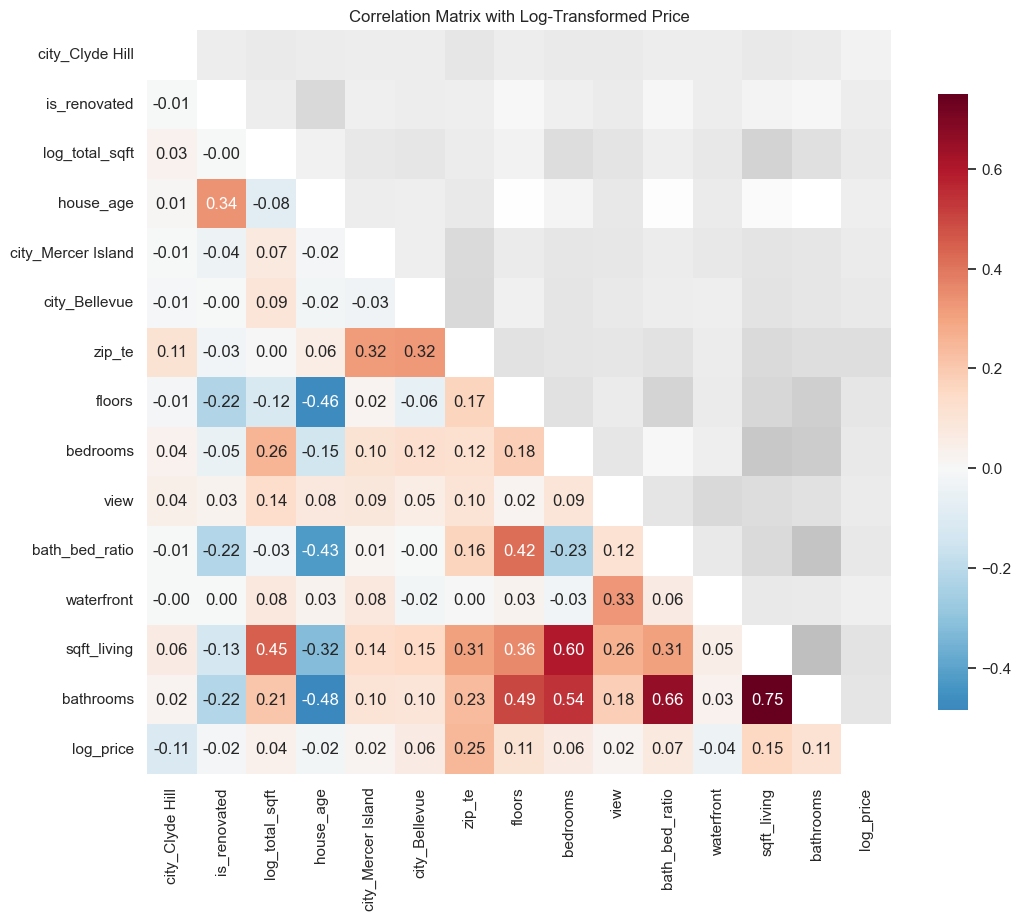

In [24]:
#train_df["log_price"] = np.log1p(train_df["price"])
#corr = train_df[final_features + ["price"]].corr()
corr = train_df[final_features + ["log_price"]].corr()


mask_lower = np.tril(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(12, 10))

sns.set_style("white")

sns.heatmap(
    corr,
    mask=mask_lower,
    cmap="Greys",
    cbar=False,
    square=True,
    linewidths=0,
    alpha=0.25
)

sns.heatmap(
    corr,
    mask=np.triu(np.ones_like(corr, dtype=bool)),
    annot=True,
    fmt=".2f",
    cmap='RdBu_r',
    center=0,
    square=True,
    linewidths=0,
    cbar_kws={"shrink": .8}
)

plt.gca().set_facecolor('white')

#plt.title("Correlation Matrix of Final Selected Features")
plt.title("Correlation Matrix with Log-Transformed Price")
plt.show()


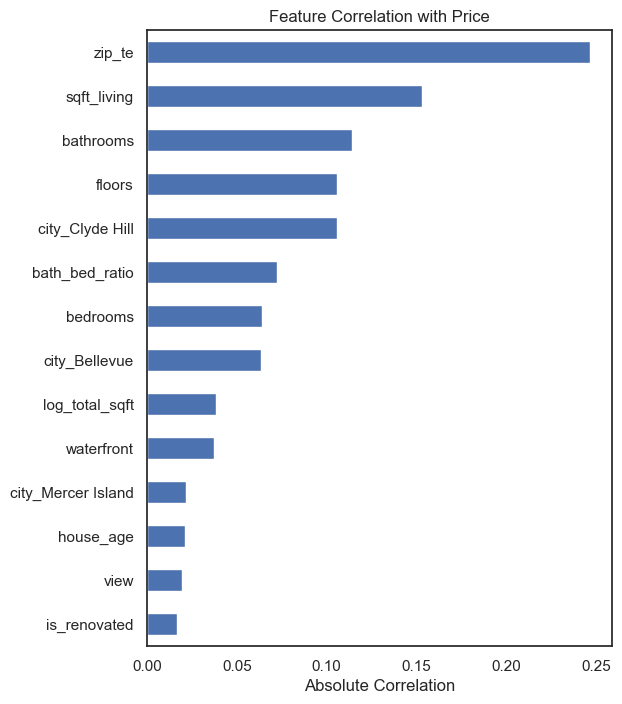

In [25]:
plt.figure(figsize=(6, 8))
corr_price[final_features].sort_values().plot(kind="barh")
plt.title("Feature Correlation with Price")
plt.xlabel("Absolute Correlation")
plt.show()

In [26]:
# Final feature selection
X_train = X_train[final_features]
X_test = X_test[final_features]

# Scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

print("Scaled train shape:", X_train_scaled.shape)
print("Scaled test shape:", X_test_scaled.shape)

Scaled train shape: (3643, 14)
Scaled test shape: (911, 14)


## Base Models

Four baseline regression models are implemented to capture different types of relationships within the dataset.

- Linear Regression (baseline)
- Random Forest (bagging)
- XGBoost (boosting)
- MLP (non-linear neural network)

These models provide a diverse set of learning strategies for comparison.

In [27]:
base_models = {
    "Linear": LinearRegression(),
    "Random Forest": RandomForestRegressor(
        n_estimators=200,
        max_depth=10,
        random_state=42
    ),
    "XGBoost": XGBRegressor(
        objective="reg:squarederror",
        n_estimators=100,
        learning_rate=0.1,
        max_depth=5,
        random_state=42
    ),
    "MLP": MLPRegressor(
        hidden_layer_sizes=(64, 32),
        max_iter=2000,
        alpha=0.001,
        learning_rate_init=0.001,
        early_stopping=True,
        n_iter_no_change=20,
        random_state=42
    )
}
results = []

for name, model in base_models.items():
    print(f"Training {name}...")

    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)

    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)

    results.append([name, rmse, r2])

results_df = pd.DataFrame(results, columns=["Model", "RMSE", "R2"])
display(results_df.sort_values(by="RMSE"))

Training Linear...
Training Random Forest...
Training XGBoost...
Training MLP...


,Model,RMSE,R2
2,XGBoost,153754.031292,0.720249
1,Random Forest,157163.063640,0.707706
0,Linear,161896.338960,0.689835
3,MLP,163172.546530,0.684926


## Cross-Validation

To evaluate model robustness, 5-fold cross-validation is performed using RMSE.

In [28]:
for name, model in base_models.items():
    scores = cross_val_score(
        model,
        X_train_scaled,
        y_train,
        cv=5,
        scoring="neg_root_mean_squared_error"
    )
    print(f"{name} CV RMSE:", -scores.mean())

Linear CV RMSE: 167853.03708868957
Random Forest CV RMSE: 163141.6622940063
XGBoost CV RMSE: 163985.93313941619
MLP CV RMSE: 167691.6899296848


## Stacking Ensemble

Stacking is used to combine predictions from multiple base models.
Out-of-fold (OOF) predictions are generated to train a meta-learner (Ridge).

In [29]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

train_oof = np.zeros((X_train_scaled.shape[0], len(base_models)))
test_preds = np.zeros((X_test_scaled.shape[0], len(base_models)))

for i, (name, model) in enumerate(base_models.items()):
    print(f"Generating OOF for {name}...")
    fold_test_preds = np.zeros((X_test_scaled.shape[0], 5))

    for fold, (train_idx, val_idx) in enumerate(kf.split(X_train_scaled, y_train)):
        model_clone = clone(model)

        X_f_train = X_train_scaled.iloc[train_idx]
        X_f_val = X_train_scaled.iloc[val_idx]
        y_f_train = y_train.iloc[train_idx]
        y_f_val = y_train.iloc[val_idx]

        model_clone.fit(X_f_train, y_f_train)

        train_oof[val_idx, i] = model_clone.predict(X_f_val)
        fold_test_preds[:, fold] = model_clone.predict(X_test_scaled)

    test_preds[:, i] = fold_test_preds.mean(axis=1)

X_meta_train = pd.DataFrame(train_oof, columns=base_models.keys(), index=X_train_scaled.index)
X_meta_test = pd.DataFrame(test_preds, columns=base_models.keys(), index=X_test_scaled.index)

# Passthrough
X_meta_train_full = pd.concat([X_meta_train, X_train_scaled], axis=1)
X_meta_test_full = pd.concat([X_meta_test, X_test_scaled], axis=1)

meta_learner = Ridge(alpha=1.0)
meta_learner.fit(X_meta_train_full, y_train)

y_final_pred = meta_learner.predict(X_meta_test_full)

final_rmse = np.sqrt(mean_squared_error(y_test, y_final_pred))
final_r2 = r2_score(y_test, y_final_pred)

print("Stacking RMSE:", final_rmse)
print("Stacking R2:", final_r2)

Generating OOF for Linear...
Generating OOF for Random Forest...
Generating OOF for XGBoost...
Generating OOF for MLP...
Stacking RMSE: 153959.30211204095
Stacking R2: 0.7195015348981302


## Ablation Study

To assess the contribution of each base model, each model is removed in turn and the stacking performance is re-evaluated.

In [30]:
ablation_results = []

model_names = list(base_models.keys())

for remove_model in model_names:
    print(f"\n--- Removing {remove_model} ---")

    ab_models = {k: v for k, v in base_models.items() if k != remove_model}

    train_oof_ab = np.zeros((X_train_scaled.shape[0], len(ab_models)))
    test_preds_ab = np.zeros((X_test_scaled.shape[0], len(ab_models)))

    for i, (name, model) in enumerate(ab_models.items()):
        fold_test_preds = np.zeros((X_test_scaled.shape[0], 5))

        for fold, (train_idx, val_idx) in enumerate(kf.split(X_train_scaled, y_train)):
            model_clone = clone(model)

            X_f_train = X_train_scaled.iloc[train_idx]
            X_f_val = X_train_scaled.iloc[val_idx]
            y_f_train = y_train.iloc[train_idx]

            model_clone.fit(X_f_train, y_f_train)

            train_oof_ab[val_idx, i] = model_clone.predict(X_f_val)
            fold_test_preds[:, fold] = model_clone.predict(X_test_scaled)

        test_preds_ab[:, i] = fold_test_preds.mean(axis=1)

    X_meta_train_ab = pd.DataFrame(train_oof_ab, columns=ab_models.keys(), index=X_train_scaled.index)
    X_meta_test_ab = pd.DataFrame(test_preds_ab, columns=ab_models.keys(), index=X_test_scaled.index)

    X_meta_train_ab_full = pd.concat([X_meta_train_ab, X_train_scaled], axis=1)
    X_meta_test_ab_full = pd.concat([X_meta_test_ab, X_test_scaled], axis=1)

    meta_ab = Ridge(alpha=1.0)
    meta_ab.fit(X_meta_train_ab_full, y_train)

    y_pred_ab = meta_ab.predict(X_meta_test_ab_full)

    rmse_ab = np.sqrt(mean_squared_error(y_test, y_pred_ab))
    r2_ab = r2_score(y_test, y_pred_ab)

    ablation_results.append([f"Remove {remove_model}", rmse_ab, r2_ab])

ablation_results.append(["Full Stacking", final_rmse, final_r2])

ablation_df = pd.DataFrame(ablation_results, columns=["Experiment", "RMSE", "R2"])
display(ablation_df.sort_values(by="RMSE"))


--- Removing Linear ---

--- Removing Random Forest ---

--- Removing XGBoost ---

--- Removing MLP ---


,Experiment,RMSE,R2
1,Remove Random Forest,153288.029413,0.721942
4,Full Stacking,153959.302112,0.719502
3,Remove MLP,154108.121946,0.718959
2,Remove XGBoost,154756.438944,0.716589
0,Remove Linear,155640.015148,0.713344


## Interpretability

Feature importance is analysed using Random Forest and SHAP values.

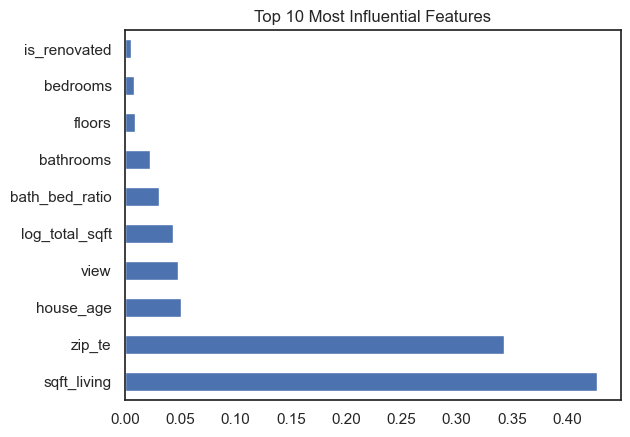

 98%|===================| 890/911 [00:20<00:00]        

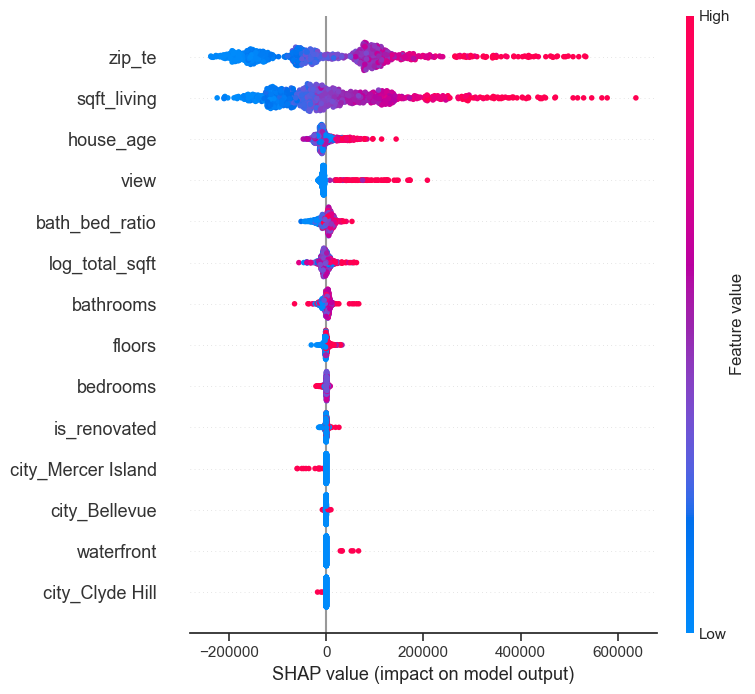

In [31]:
rf_temp = RandomForestRegressor(n_estimators=100, random_state=42)
rf_temp.fit(X_train_scaled, y_train)

importances = pd.Series(rf_temp.feature_importances_, index=X_train_scaled.columns)
importances.nlargest(10).plot(kind="barh")
plt.title("Top 10 Most Influential Features")
plt.show()

explainer = shap.Explainer(rf_temp, X_train_scaled)
shap_values = explainer(X_test_scaled, check_additivity=False)

shap.summary_plot(shap_values, X_test_scaled)

## Improved Models

Hyperparameter tuning is applied to improve model performance.

In [32]:
print("\n=== Ridge Tuning ===")

for a in [0.1, 1, 10, 50]:
    model = Ridge(alpha=a)
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)

    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)

    print(f"alpha={a} | RMSE={rmse:.2f} | R2={r2:.4f}")

best_ridge = Ridge(alpha=0.1) 


=== Ridge Tuning ===
alpha=0.1 | RMSE=161897.39 | R2=0.6898
alpha=1 | RMSE=161906.83 | R2=0.6898
alpha=10 | RMSE=161998.19 | R2=0.6894
alpha=50 | RMSE=162360.69 | R2=0.6881


In [33]:
param_grid = {
    "n_estimators": [100, 150, 200],
    "learning_rate": [0.03, 0.05, 0.08],
    "max_depth": [3, 4, 5],
    "subsample": [0.8, 0.9],
    "colsample_bytree": [0.8, 0.9]
}

xgb = XGBRegressor(
    objective="reg:squarederror",
    random_state=42
)

grid = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train_scaled, y_train)
print("Best Parameters from GridSearch:", grid.best_params_)

best_xgb = grid.best_estimator_


Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best Parameters from GridSearch: {'colsample_bytree': 0.8, 'learning_rate': 0.03, 'max_depth': 5, 'n_estimators': 100, 'subsample': 0.9}


In [34]:
improved_models = {
    "Linear (Ridge)": Ridge(alpha=0.1),

    "Random Forest": RandomForestRegressor(
        n_estimators=200,
        max_depth=10,
        random_state=42
    ),

    "XGBoost (Tuned)": best_xgb,

    "MLP (Stable)": MLPRegressor(
        hidden_layer_sizes=(64, 32),
        max_iter=2000,
        alpha=0.001,
        learning_rate_init=0.001,
        early_stopping=True,
        n_iter_no_change=20,
        random_state=42
    )
}

results_improved = []

for name, model in improved_models.items():
    print(f"Training {name}...")
    
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)

    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)
    
    results_improved.append([name, rmse, r2])

df_improved = pd.DataFrame(results_improved, columns=["Model", "RMSE", "R2"])

print("\n=== Improved Models Performance ===")
display(df_improved.sort_values(by="RMSE"))

Training Linear (Ridge)...
Training Random Forest...
Training XGBoost (Tuned)...
Training MLP (Stable)...

=== Improved Models Performance ===


,Model,RMSE,R2
2,XGBoost (Tuned),156455.312234,0.710333
1,Random Forest,157163.063640,0.707706
0,Linear (Ridge),161897.391196,0.689831
3,MLP (Stable),163172.546530,0.684926


## Improved Stacking

Stacking is repeated using tuned models.

In [35]:
stack_models = {
    "RF": improved_models["Random Forest"],
    "XGB": best_xgb
}

meta_learner = Ridge(alpha=0.1)

kf = KFold(n_splits=5, shuffle=True, random_state=42)

train_oof = np.zeros((X_train_scaled.shape[0], len(stack_models)))
test_preds = np.zeros((X_test_scaled.shape[0], len(stack_models)))

for i, (name, model) in enumerate(stack_models.items()):
    print(f"Generating OOF for {name}...")
    
    fold_test_preds = np.zeros((X_test_scaled.shape[0], 5))
    
    for fold, (train_idx, val_idx) in enumerate(kf.split(X_train_scaled, y_train)):
        
        model_clone = clone(model)

        X_f_train = X_train_scaled.iloc[train_idx]
        X_f_val = X_train_scaled.iloc[val_idx]
        y_f_train = y_train.iloc[train_idx]

        model_clone.fit(X_f_train, y_f_train)

        train_oof[val_idx, i] = model_clone.predict(X_f_val)
        fold_test_preds[:, fold] = model_clone.predict(X_test_scaled)

    test_preds[:, i] = fold_test_preds.mean(axis=1)

X_meta_train = pd.DataFrame(
    train_oof,
    columns=stack_models.keys(),
    index=X_train_scaled.index
)

X_meta_test = pd.DataFrame(
    test_preds,
    columns=stack_models.keys(),
    index=X_test_scaled.index
)

X_meta_train_full = pd.concat([X_meta_train, X_train_scaled], axis=1)
X_meta_test_full = pd.concat([X_meta_test, X_test_scaled], axis=1)


X_meta_train_full = X_meta_train_full.fillna(0)
X_meta_test_full = X_meta_test_full.fillna(0)

meta_learner.fit(X_meta_train_full, y_train)

y_pred_stack = meta_learner.predict(X_meta_test_full)

rmse_stack = np.sqrt(mean_squared_error(y_test, y_pred_stack))
r2_stack = r2_score(y_test, y_pred_stack)

print("\n=== FINAL STACKING ===")
print("RMSE:", rmse_stack)
print("R2:", r2_stack)

Generating OOF for RF...
Generating OOF for XGB...

=== FINAL STACKING ===
RMSE: 155081.41606429112
R2: 0.7153978756801019


## Impact of Preprocessing

This section compares model performance before and after preprocessing.

In [36]:
print("\n=== Before Processing ===")

df_raw = df_original.copy()

X_raw = df_raw.drop(columns=["price"])
y_raw = df_raw["price"]

X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
    X_raw, y_raw,
    test_size=0.2,
    random_state=42
)

# encoding
X_train_raw = pd.get_dummies(X_train_raw, drop_first=True)
X_test_raw = pd.get_dummies(X_test_raw, drop_first=True)

X_train_raw, X_test_raw = X_train_raw.align(
    X_test_raw, join='left', axis=1, fill_value=0
)

results_before = []

rf = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42)
xgb = XGBRegressor(
    objective="reg:squarederror",
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42
)

rf.fit(X_train_raw, y_train_raw)
rf_preds = rf.predict(X_test_raw)

results_before.append([
    "Random Forest",
    np.sqrt(mean_squared_error(y_test_raw, rf_preds)),
    r2_score(y_test_raw, rf_preds)
])

# XGBoost
xgb.fit(X_train_raw, y_train_raw)
xgb_preds = xgb.predict(X_test_raw)

results_before.append([
    "XGBoost",
    np.sqrt(mean_squared_error(y_test_raw, xgb_preds)),
    r2_score(y_test_raw, xgb_preds)
])

df_before = pd.DataFrame(results_before, columns=["Model", "RMSE", "R2"])
display(df_before)


=== Before Processing ===


,Model,RMSE,R2
0,Random Forest,986508.316739,0.04574
1,XGBoost,980332.593436,0.05765


In [37]:
print("\n=== After Processing ===")

results_after = []

rf_after = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42)
xgb_after = XGBRegressor(
    objective="reg:squarederror",
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42
)

# Random Forest
rf_after.fit(X_train, y_train)
rf_preds = rf_after.predict(X_test)

results_after.append([
    "After",
    "Random Forest",
    np.sqrt(mean_squared_error(y_test, rf_preds)),
    r2_score(y_test, rf_preds)
])

# XGBoost
xgb_after.fit(X_train, y_train)
xgb_preds = xgb_after.predict(X_test)

results_after.append([
    "After",
    "XGBoost",
    np.sqrt(mean_squared_error(y_test, xgb_preds)),
    r2_score(y_test, xgb_preds)
])

df_after = pd.DataFrame(results_after, columns=["Setting", "Model", "RMSE", "R2"])
display(df_after)


=== After Processing ===


,Setting,Model,RMSE,R2
0,After,Random Forest,157147.668203,0.707763
1,After,XGBoost,152971.630935,0.723089


,Model,RMSE,R2,Dataset,Setting
0,Random Forest,986508.316739,0.045740,Before,NaN
1,XGBoost,980332.593436,0.057650,Before,NaN
2,Random Forest,157147.668203,0.707763,After,After
3,XGBoost,152971.630935,0.723089,After,After


,Dataset,Model,RMSE,R2
0,Before,Random Forest,986508.316739,0.045740
1,Before,XGBoost,980332.593436,0.057650
2,After,Random Forest,157147.668203,0.707763
3,After,XGBoost,152971.630935,0.723089


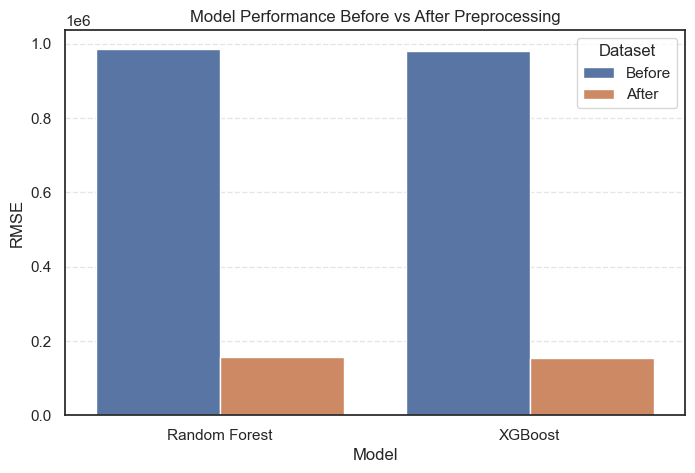

In [38]:
df_before["Dataset"] = "Before"
df_after["Dataset"] = "After"

df_compare = pd.concat([df_before, df_after], ignore_index=True)
display(df_compare)
display(df_compare[["Dataset", "Model", "RMSE", "R2"]])

plt.figure(figsize=(8, 5))
sns.barplot(
    data=df_compare,
    x="Model",
    y="RMSE",
    hue="Dataset"
)

plt.title("Model Performance Before vs After Preprocessing")
plt.ylabel("RMSE")
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()